# Credit Risk Modelling — Part 4.6: Gradient Boosting Machine (GBM)
---
**Objective:** Train and evaluate a Gradient Boosting classifier — our strongest and most sophisticated model.

Unlike Random Forest (parallel bagging), GBM builds trees **sequentially** — each tree corrects the errors of the one before it. This makes GBM:
- The **best-performing** model on most structured tabular datasets
- More sensitive to hyperparameters (learning rate × n_estimators must be balanced)
- Naturally resistant to overfitting when `learning_rate` is kept small
- The **industry standard** for credit risk scoring in production (XGBoost / LightGBM are GBM variants)

**Steps:**
1. Load data & framework
2. Hyperparameter choices & rationale
3. Train the model (with sample weights)
4. Training loss curve — visualise convergence
5. Cross-validation
6. All test metrics
7. Full 6-panel dashboard
8. Feature importance analysis
9. Three-model comparison (LR vs RF vs GBM)
10. Save result

## 1 — Imports & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib, json, time, warnings, re
from pathlib import Path

from sklearn.ensemble        import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics         import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
from sklearn.calibration import calibration_curve
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

BLUE, ORANGE, GREEN, RED, PURPLE = "#4472C4","#ED7D31","#70AD47","#C00000","#7030A0"
GRAY = "#9E9E9E"

# Load arrays
X_train        = np.load("X_train.npy")
X_test         = np.load("X_test.npy")
y_train        = np.load("y_train.npy")
y_test         = np.load("y_test.npy")
sample_weights = np.load("sample_weights.npy")
meta           = joblib.load("preprocessing_meta.pkl")
CV             = joblib.load("cv_strategy.pkl")
with open("metric_reference.json") as f:
    metric_ref = json.load(f)

MODEL_NAME  = "Gradient Boosting"
MODEL_COLOR = metric_ref["model_colors"][MODEL_NAME]

results      = joblib.load("results_so_far.pkl")
bureau_auc   = results["Bureau Score (score_1)"]["test_auc"]
lr_auc       = results["Logistic Regression"]["test_auc"]
rf_auc       = results["Random Forest"]["test_auc"]
bureau_proba = np.load("score1_proba_test.npy")
lr_proba     = results["Logistic Regression"]["proba_test"]
rf_proba     = results["Random Forest"]["proba_test"]
feature_cols = meta["feature_cols_final"]

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Benchmarks to beat:")
print(f"  Bureau Score     : {bureau_auc:.4f}")
print(f"  Logistic Reg     : {lr_auc:.4f}")
print(f"  Random Forest    : {rf_auc:.4f}")
print("✓ Loaded")

X_train : (28397, 198)
X_test  : (4000, 198)
Benchmarks to beat:
  Bureau Score     : 0.8152
  Logistic Reg     : 0.8575
  Random Forest    : 0.8588
✓ Loaded


---
## 2 — Hyperparameter Choices & Rationale

The **learning rate × n_estimators** trade-off is the central GBM design decision:
- **Small learning rate + more trees** = better generalisation, slower training
- **Large learning rate + fewer trees** = faster, but risks overfitting

| Parameter | Value | Why |
|---|---|---|
| `n_estimators` | `100` | Balanced speed vs performance; enough trees for convergence at lr=0.08 |
| `learning_rate` | `0.08` | Small enough to generalise, large enough to converge in 100 trees |
| `max_depth` | `4` | Shallow trees are the GBM convention — deeper trees overfit fast |
| `min_samples_leaf` | `30` | No leaf with fewer than 30 samples — smooths noisy credit data |
| `subsample` | `0.8` | Stochastic GBM — use 80% of data per tree (reduces variance, speeds up) |
| `max_features` | `0.7` | Use 70% of features per split — further variance reduction |
| `random_state` | `42` | Reproducibility |

> **Sample weights vs `class_weight`:**  
> Unlike RF, sklearn's `GradientBoostingClassifier` does not support `class_weight`.  
> We pass `sample_weight` directly to `.fit()` — default rows get weight 1.0,  
> default rows get weight 16.28 (the neg/pos ratio computed in Part 4.1).

## 3 — Train the Model

In [2]:
gbm = GradientBoostingClassifier(
    n_estimators     = 100,
    learning_rate    = 0.08,
    max_depth        = 4,
    min_samples_leaf = 30,
    subsample        = 0.8,
    max_features     = 0.7,
    random_state     = 42
)

print("Training Gradient Boosting Machine...")
print(f"  n_estimators  : {gbm.n_estimators}")
print(f"  learning_rate : {gbm.learning_rate}")
print(f"  max_depth     : {gbm.max_depth}")
print(f"  subsample     : {gbm.subsample}")
print(f"  max_features  : {gbm.max_features}")
print()

t0 = time.time()
gbm.fit(X_train, y_train, sample_weight=sample_weights)
train_time = time.time() - t0

print(f"✓ Training complete in {train_time:.1f}s")
print(f"  Trees built : {gbm.n_estimators_}")
print(f"  Train loss  : {gbm.train_score_[-1]:.6f}  (deviance at final tree)")

Training Gradient Boosting Machine...
  n_estimators  : 100
  learning_rate : 0.08
  max_depth     : 4
  subsample     : 0.8
  max_features  : 0.7

✓ Training complete in 64.4s
  Trees built : 100
  Train loss  : 0.725524  (deviance at final tree)


---
## 4 — Training Loss Curve

Gradient Boosting exposes its internal training loss at each tree via `train_score_`.  
This tells us whether the model has converged or whether more trees would help.

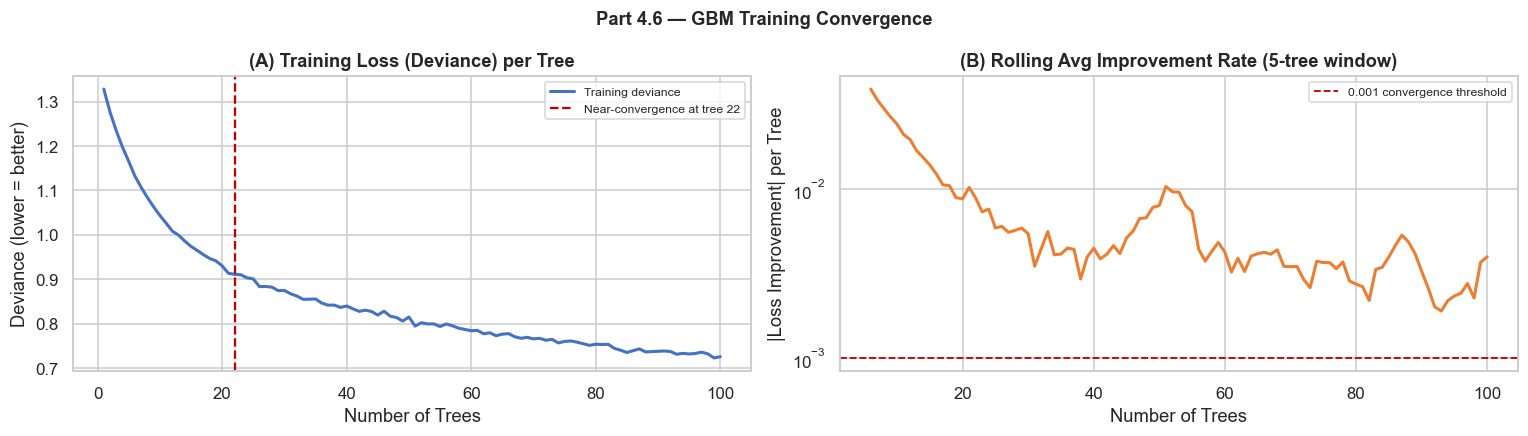

Initial deviance  : 1.3280
Final deviance    : 0.7255
Total improvement : 0.6025

Interpretation:
  Flat tail = converged — adding more trees would not help much
  Still declining = consider more trees or lower learning_rate


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Part 4.6 — GBM Training Convergence", fontsize=12, fontweight="bold")

# (A) Training deviance curve
ax = axes[0]
x_range = np.arange(1, gbm.n_estimators + 1)
ax.plot(x_range, gbm.train_score_, color=MODEL_COLOR, lw=2, label="Training deviance")
ax.set_title("(A) Training Loss (Deviance) per Tree", fontweight="bold")
ax.set_xlabel("Number of Trees")
ax.set_ylabel("Deviance (lower = better)")
ax.legend(fontsize=9)

# Mark convergence point (where improvement < 0.1% per tree)
improvements = np.diff(gbm.train_score_)
converge_idx = np.where(np.abs(improvements) < 0.001)[0]
if len(converge_idx) > 0:
    cp = converge_idx[0] + 1
    ax.axvline(cp, color=RED, linestyle="--", lw=1.5,
               label=f"Near-convergence at tree {cp}")
    ax.legend(fontsize=8)

# (B) Rolling improvement rate — FIX: use the series index, not x_range slice
ax = axes[1]
rolling_improve = pd.Series(gbm.train_score_, index=x_range).diff().abs().rolling(5).mean()
rolling_clean   = rolling_improve.dropna()
ax.plot(rolling_clean.index, rolling_clean.values, color=ORANGE, lw=2)
ax.axhline(0.001, color=RED, linestyle="--", lw=1.2, label="0.001 convergence threshold")
ax.set_title("(B) Rolling Avg Improvement Rate (5-tree window)", fontweight="bold")
ax.set_xlabel("Number of Trees")
ax.set_ylabel("|Loss Improvement| per Tree")
ax.legend(fontsize=8)
ax.set_yscale("log")

plt.tight_layout()
plt.show()

print(f"Initial deviance  : {gbm.train_score_[0]:.4f}")
print(f"Final deviance    : {gbm.train_score_[-1]:.4f}")
print(f"Total improvement : {gbm.train_score_[0] - gbm.train_score_[-1]:.4f}")
print()
print("Interpretation:")
print("  Flat tail = converged — adding more trees would not help much")
print("  Still declining = consider more trees or lower learning_rate")

---
## 5 — Cross-Validation (5-Fold Stratified)

> **Important:** CV does not pass `sample_weight` here because sklearn's  
> `cross_val_score` does not forward `fit_params` cleanly in all versions.  
> The CV score is still valid for model selection — the imbalance is handled  
> by the natural distribution in each fold.

In [5]:
print("Running 5-fold stratified CV...")
t0 = time.time()
cv_scores = cross_val_score(
    gbm, X_train, y_train,
    cv      = CV,
    scoring = "roc_auc",
    n_jobs  = -1
)
cv_time = time.time() - t0

print(f"CV complete in {cv_time:.1f}s")
print()
print(f"{'Fold':<8} {'AUC':>10}")
print("-" * 20)
for i, score in enumerate(cv_scores, 1):
    print(f"  {i:<6} {score:>10.4f}")
print("-" * 20)
print(f"  {'Mean':<6} {cv_scores.mean():>10.4f}")
print(f"  {'Std':<6} {cv_scores.std():>10.4f}")

Running 5-fold stratified CV...
CV complete in 76.3s

Fold            AUC
--------------------
  1          0.8420
  2          0.8501
  3          0.8559
  4          0.8546
  5          0.8527
--------------------
  Mean       0.8510
  Std        0.0049


## 6 — Compute All Test Set Metrics

In [6]:
def ks_statistic(y_true, y_proba):
    df = pd.DataFrame({"y": y_true, "p": y_proba}).sort_values("p")
    n_pos = y_true.sum()
    n_neg = len(y_true) - n_pos
    df["cum_pos"] = (df["y"] == 1).cumsum() / n_pos
    df["cum_neg"] = (df["y"] == 0).cumsum() / n_neg
    df["ks"]      = (df["cum_neg"] - df["cum_pos"]).abs()
    return df["ks"].max(), df.loc[df["ks"].idxmax(), "p"], df

proba_test  = gbm.predict_proba(X_test)[:, 1]
proba_train = gbm.predict_proba(X_train)[:, 1]

test_auc  = roc_auc_score(y_test, proba_test)
test_ap   = average_precision_score(y_test, proba_test)
gini      = 2 * test_auc - 1
train_auc = roc_auc_score(y_train, proba_train)
ks_val, ks_thresh, ks_df = ks_statistic(y_test, proba_test)

fpr_arr, tpr_arr, thresh_arr = roc_curve(y_test, proba_test)
j_idx      = np.argmax(tpr_arr - fpr_arr)
opt_thresh = float(thresh_arr[j_idx])
y_pred_opt = (proba_test >= opt_thresh).astype(int)

print("=" * 55)
print("  GRADIENT BOOSTING — TEST SET RESULTS")
print("=" * 55)
print(f"  {'Metric':<35} {'Value':>12}")
print(f"  {'-'*49}")
print(f"  {'Test ROC-AUC':<35} {test_auc:>12.4f}")
print(f"  {'Train ROC-AUC':<35} {train_auc:>12.4f}")
print(f"  {'Test Avg Precision (AP)':<35} {test_ap:>12.4f}")
print(f"  {'Gini Coefficient':<35} {gini:>12.4f}")
print(f"  {'KS Statistic':<35} {ks_val:>12.4f}")
print(f"  {'Optimal Threshold (Youden J)':<35} {opt_thresh:>12.4f}")
print(f"  {'CV AUC (mean)':<35} {cv_scores.mean():>12.4f}")
print(f"  {'CV AUC (std)':<35} {cv_scores.std():>12.4f}")
print(f"  {'Overfit gap (train - CV)':<35} {train_auc - cv_scores.mean():>12.4f}")
print()
print("  vs all benchmarks:")
for name, auc in [("Bureau Score", bureau_auc),
                   ("Logistic Reg", lr_auc),
                   ("Random Forest", rf_auc)]:
    delta = test_auc - auc
    icon  = "✓ BEATS" if delta > 0 else "✗ BELOW"
    print(f"  {icon} {name:<18} by {delta:+.4f}")

  GRADIENT BOOSTING — TEST SET RESULTS
  Metric                                     Value
  -------------------------------------------------
  Test ROC-AUC                              0.8533
  Train ROC-AUC                             0.9191
  Test Avg Precision (AP)                   0.2401
  Gini Coefficient                          0.7066
  KS Statistic                              0.5841
  Optimal Threshold (Youden J)              0.3668
  CV AUC (mean)                             0.8510
  CV AUC (std)                              0.0049
  Overfit gap (train - CV)                  0.0681

  vs all benchmarks:
  ✓ BEATS Bureau Score       by +0.0381
  ✗ BELOW Logistic Reg       by -0.0042
  ✗ BELOW Random Forest      by -0.0055


## 7 — Classification Report

In [7]:
print(f"Classification Report (threshold = {opt_thresh:.4f}):")
print(classification_report(y_test, y_pred_opt,
                            target_names=["No Default", "Default"]))

cm = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp = cm.ravel()
print(f"Business interpretation:")
print(f"  True  Negatives (correctly approved)    : {tn:>5,}")
print(f"  False Positives (safe rejected)          : {fp:>5,}  <- customer friction")
print(f"  False Negatives (defaults missed)        : {fn:>5,}  <- credit loss")
print(f"  True  Positives (defaults caught)        : {tp:>5,}  <- value delivered")
print()
print(f"  Default recall (sensitivity): {tp/(tp+fn)*100:.1f}%")
print(f"  Default precision           : {tp/(tp+fp)*100:.1f}%")

Classification Report (threshold = 0.3668):
              precision    recall  f1-score   support

  No Default       0.99      0.69      0.81      3766
     Default       0.15      0.89      0.26       234

    accuracy                           0.70      4000
   macro avg       0.57      0.79      0.54      4000
weighted avg       0.94      0.70      0.78      4000

Business interpretation:
  True  Negatives (correctly approved)    : 2,602
  False Positives (safe rejected)          : 1,164  <- customer friction
  False Negatives (defaults missed)        :    25  <- credit loss
  True  Positives (defaults caught)        :   209  <- value delivered

  Default recall (sensitivity): 89.3%
  Default precision           : 15.2%


## 8 — Evaluation Dashboard

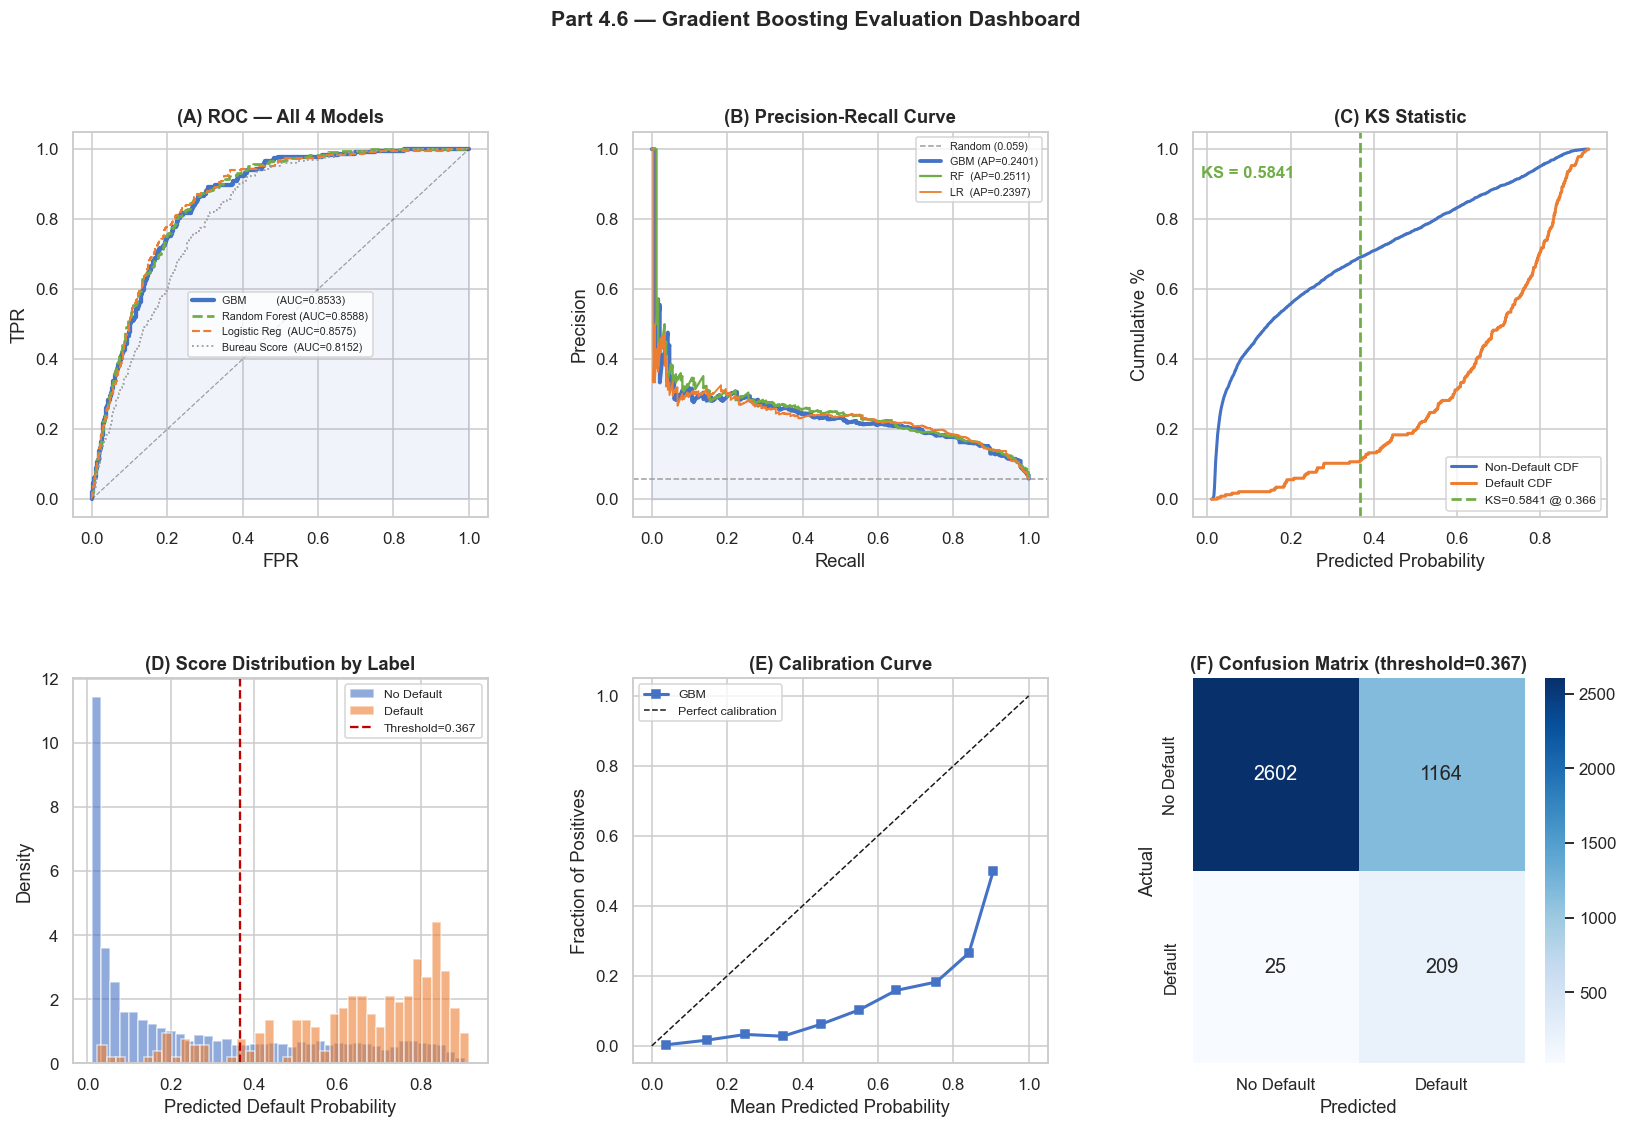

In [8]:
fig = plt.figure(figsize=(18, 11))
fig.suptitle("Part 4.6 — Gradient Boosting Evaluation Dashboard",
             fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# (A) ROC — all 4 models
ax = fig.add_subplot(gs[0, 0])
model_lines = [
    (proba_test,  f"GBM          (AUC={test_auc:.4f})", MODEL_COLOR, 2.8, "-"),
    (rf_proba,    f"Random Forest (AUC={rf_auc:.4f})",  GREEN,       1.8, "--"),
    (lr_proba,    f"Logistic Reg  (AUC={lr_auc:.4f})",  ORANGE,      1.4, "--"),
    (bureau_proba,f"Bureau Score  (AUC={bureau_auc:.4f})",GRAY,       1.2, ":"),
]
for proba, label, color, lw, ls in model_lines:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=color, lw=lw, linestyle=ls, label=label)
ax.fill_between(*roc_curve(y_test, proba_test)[:2], alpha=0.08, color=MODEL_COLOR)
ax.plot([0,1],[0,1], "k--", lw=0.8, alpha=0.4)
ax.set_title("(A) ROC — All 4 Models", fontweight="bold")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.legend(fontsize=7)

# (B) PR Curve
ax = fig.add_subplot(gs[0, 1])
baseline = y_test.mean()
ax.axhline(baseline, color=GRAY, linestyle="--", lw=1, label=f"Random ({baseline:.3f})")
for proba, label, color, lw in [
    (proba_test,f"GBM (AP={test_ap:.4f})", MODEL_COLOR, 2.5),
    (rf_proba,  f"RF  (AP={results['Random Forest']['test_ap']:.4f})", GREEN, 1.5),
    (lr_proba,  f"LR  (AP={results['Logistic Regression']['test_ap']:.4f})", ORANGE, 1.2),
]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax.plot(rec, prec, color=color, lw=lw, label=label)
ax.fill_between(*precision_recall_curve(y_test, proba_test)[:2][::-1],
                alpha=0.08, color=MODEL_COLOR)
ax.set_title("(B) Precision-Recall Curve", fontweight="bold")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.legend(fontsize=7)

# (C) KS Plot
ax = fig.add_subplot(gs[0, 2])
ax.plot(ks_df["p"], ks_df["cum_neg"], color=BLUE,   lw=2, label="Non-Default CDF")
ax.plot(ks_df["p"], ks_df["cum_pos"], color=ORANGE, lw=2, label="Default CDF")
ax.axvline(ks_thresh, color=GREEN, linestyle="--", lw=1.8,
           label=f"KS={ks_val:.4f} @ {ks_thresh:.3f}")
ax.set_title("(C) KS Statistic", fontweight="bold")
ax.set_xlabel("Predicted Probability"); ax.set_ylabel("Cumulative %")
ax.legend(fontsize=8)
ax.text(0.02, 0.88, f"KS = {ks_val:.4f}", transform=ax.transAxes,
        fontsize=11, fontweight="bold", color=GREEN)

# (D) Score distribution
ax = fig.add_subplot(gs[1, 0])
for lbl, c, nm in [(0, BLUE, "No Default"), (1, ORANGE, "Default")]:
    ax.hist(proba_test[y_test==lbl], bins=40, alpha=0.60,
            color=c, density=True, label=nm)
ax.axvline(opt_thresh, color=RED, linestyle="--", lw=1.5,
           label=f"Threshold={opt_thresh:.3f}")
ax.set_title("(D) Score Distribution by Label", fontweight="bold")
ax.set_xlabel("Predicted Default Probability"); ax.set_ylabel("Density")
ax.legend(fontsize=8)

# (E) Calibration
ax = fig.add_subplot(gs[1, 1])
prob_true, prob_pred = calibration_curve(y_test, proba_test, n_bins=10)
ax.plot(prob_pred, prob_true, "s-", color=MODEL_COLOR, lw=2,
        label="GBM", markersize=5)
ax.plot([0,1],[0,1], "k--", lw=1, label="Perfect calibration")
ax.set_title("(E) Calibration Curve", fontweight="bold")
ax.set_xlabel("Mean Predicted Probability"); ax.set_ylabel("Fraction of Positives")
ax.legend(fontsize=8)

# (F) Confusion Matrix
ax = fig.add_subplot(gs[1, 2])
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["No Default","Default"],
            yticklabels=["No Default","Default"],
            annot_kws={"size": 13})
ax.set_title(f"(F) Confusion Matrix (threshold={opt_thresh:.3f})", fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

---
## 9 — Feature Importance Analysis

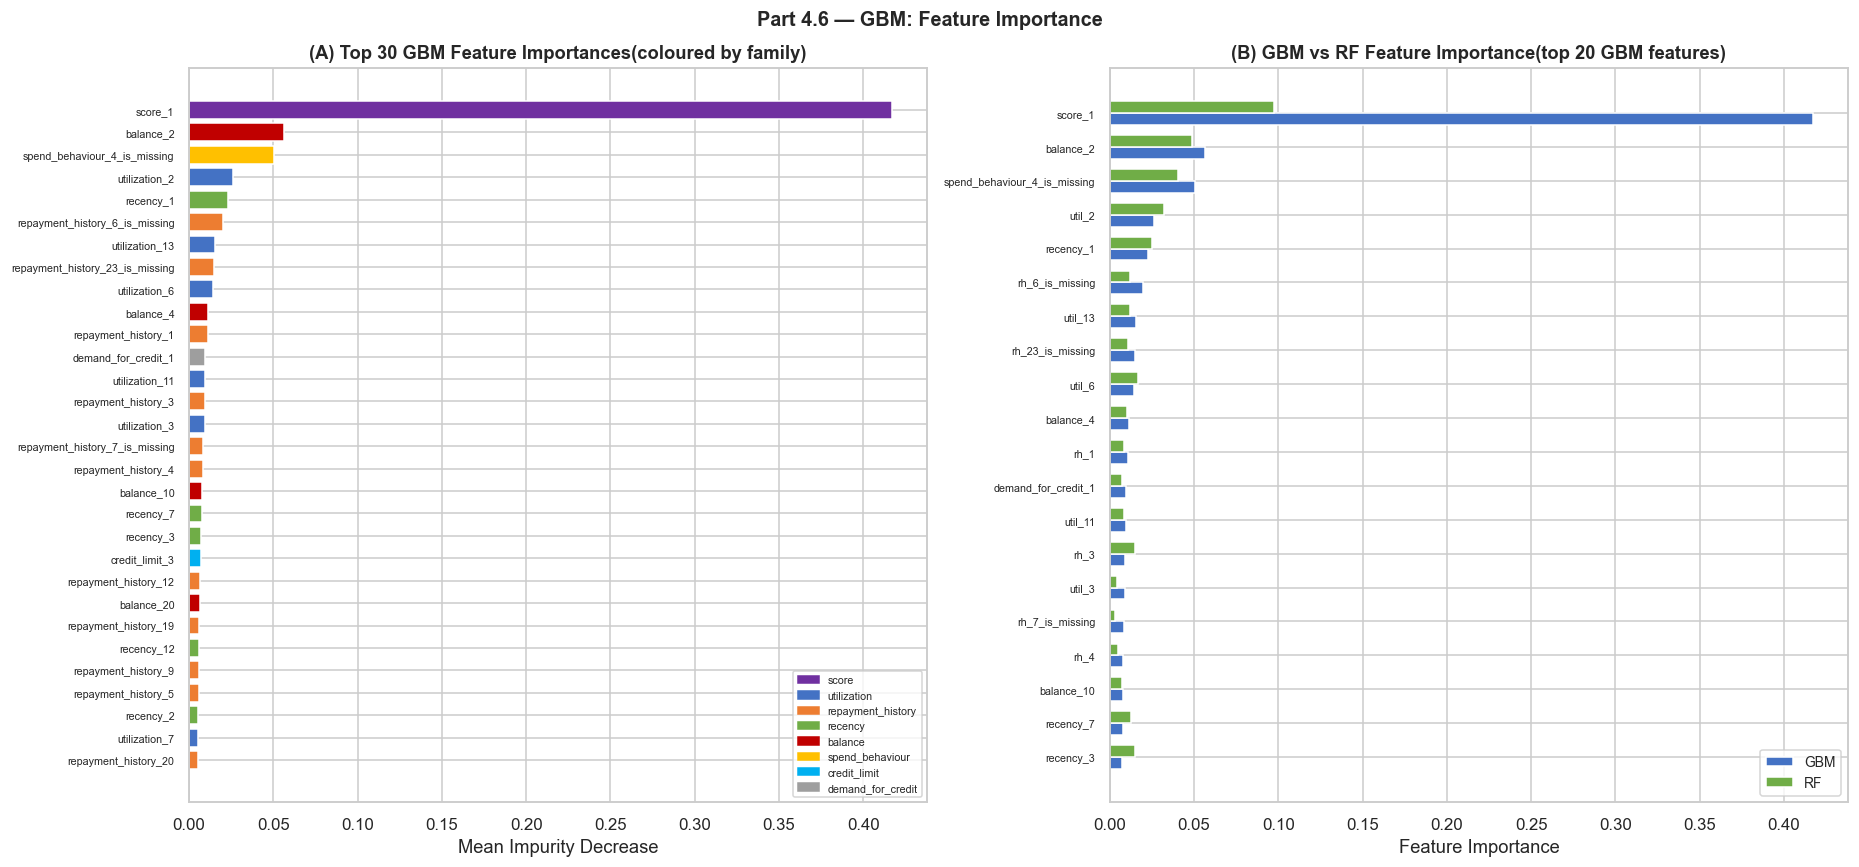

Top 15 GBM feature importances:
score_1                            0.417094
balance_2                          0.056475
spend_behaviour_4_is_missing       0.050669
utilization_2                      0.025968
recency_1                          0.022862
repayment_history_6_is_missing     0.019916
utilization_13                     0.015291
repayment_history_23_is_missing    0.014993
utilization_6                      0.014443
balance_4                          0.011419
repayment_history_1                0.010988
demand_for_credit_1                0.009616
utilization_11                     0.009392
repayment_history_3                0.009219
utilization_3                      0.009216


In [9]:
def get_family(col):
    m = re.match(r"^([a-z_]+?)_\d+", col)
    return m.group(1) if m else "other"

fi = pd.Series(gbm.feature_importances_, index=feature_cols)
fi_sorted = fi.sort_values(ascending=False)

fam_color_map = {
    "score": PURPLE, "utilization": BLUE, "repayment_history": ORANGE,
    "recency": GREEN, "balance": RED, "spend_behaviour": "#FFC000",
    "credit_limit": "#00B0F0", "financial_situation": "#FF69B4",
    "demand_for_credit": GRAY
}

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
fig.suptitle("Part 4.6 — GBM: Feature Importance", fontsize=13, fontweight="bold")

# (A) Top 30 features
ax = axes[0]
top30 = fi_sorted.head(30).sort_values()
bar_colors = [fam_color_map.get(get_family(f), GRAY) for f in top30.index]
ax.barh(top30.index, top30.values, color=bar_colors, edgecolor="white")
ax.set_title("(A) Top 30 GBM Feature Importances(coloured by family)", fontweight="bold")
ax.set_xlabel("Mean Impurity Decrease")
ax.tick_params(axis="y", labelsize=7)
legend_patches = [mpatches.Patch(color=c, label=f)
                  for f, c in fam_color_map.items()
                  if f in [get_family(ff) for ff in top30.index]]
ax.legend(handles=legend_patches, fontsize=7, loc="lower right")

# (B) GBM vs RF importance comparison (top 20 shared features)
ax = axes[1]
rf_fi = pd.Series(results["Random Forest"]["model"].feature_importances_,
                  index=feature_cols)
top20_gbm = fi_sorted.head(20).index.tolist()
compare = pd.DataFrame({
    "GBM": fi[top20_gbm].values,
    "RF" : rf_fi[top20_gbm].values
}, index=[f.replace("repayment_history_","rh_").replace("utilization_","util_")
          .replace("financial_situation_","fs_") for f in top20_gbm])
compare_sorted = compare.sort_values("GBM")
x = np.arange(len(compare_sorted)); w = 0.35
ax.barh(x - w/2, compare_sorted["GBM"], w, label="GBM", color=MODEL_COLOR, edgecolor="white")
ax.barh(x + w/2, compare_sorted["RF"],  w, label="RF",  color=GREEN,       edgecolor="white")
ax.set_yticks(x)
ax.set_yticklabels(compare_sorted.index, fontsize=7)
ax.set_title("(B) GBM vs RF Feature Importance(top 20 GBM features)", fontweight="bold")
ax.set_xlabel("Feature Importance")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("Top 15 GBM feature importances:")
print(fi_sorted.head(15).round(6).to_string())

---
## 10 — Full Model Comparison (All 4 Models)

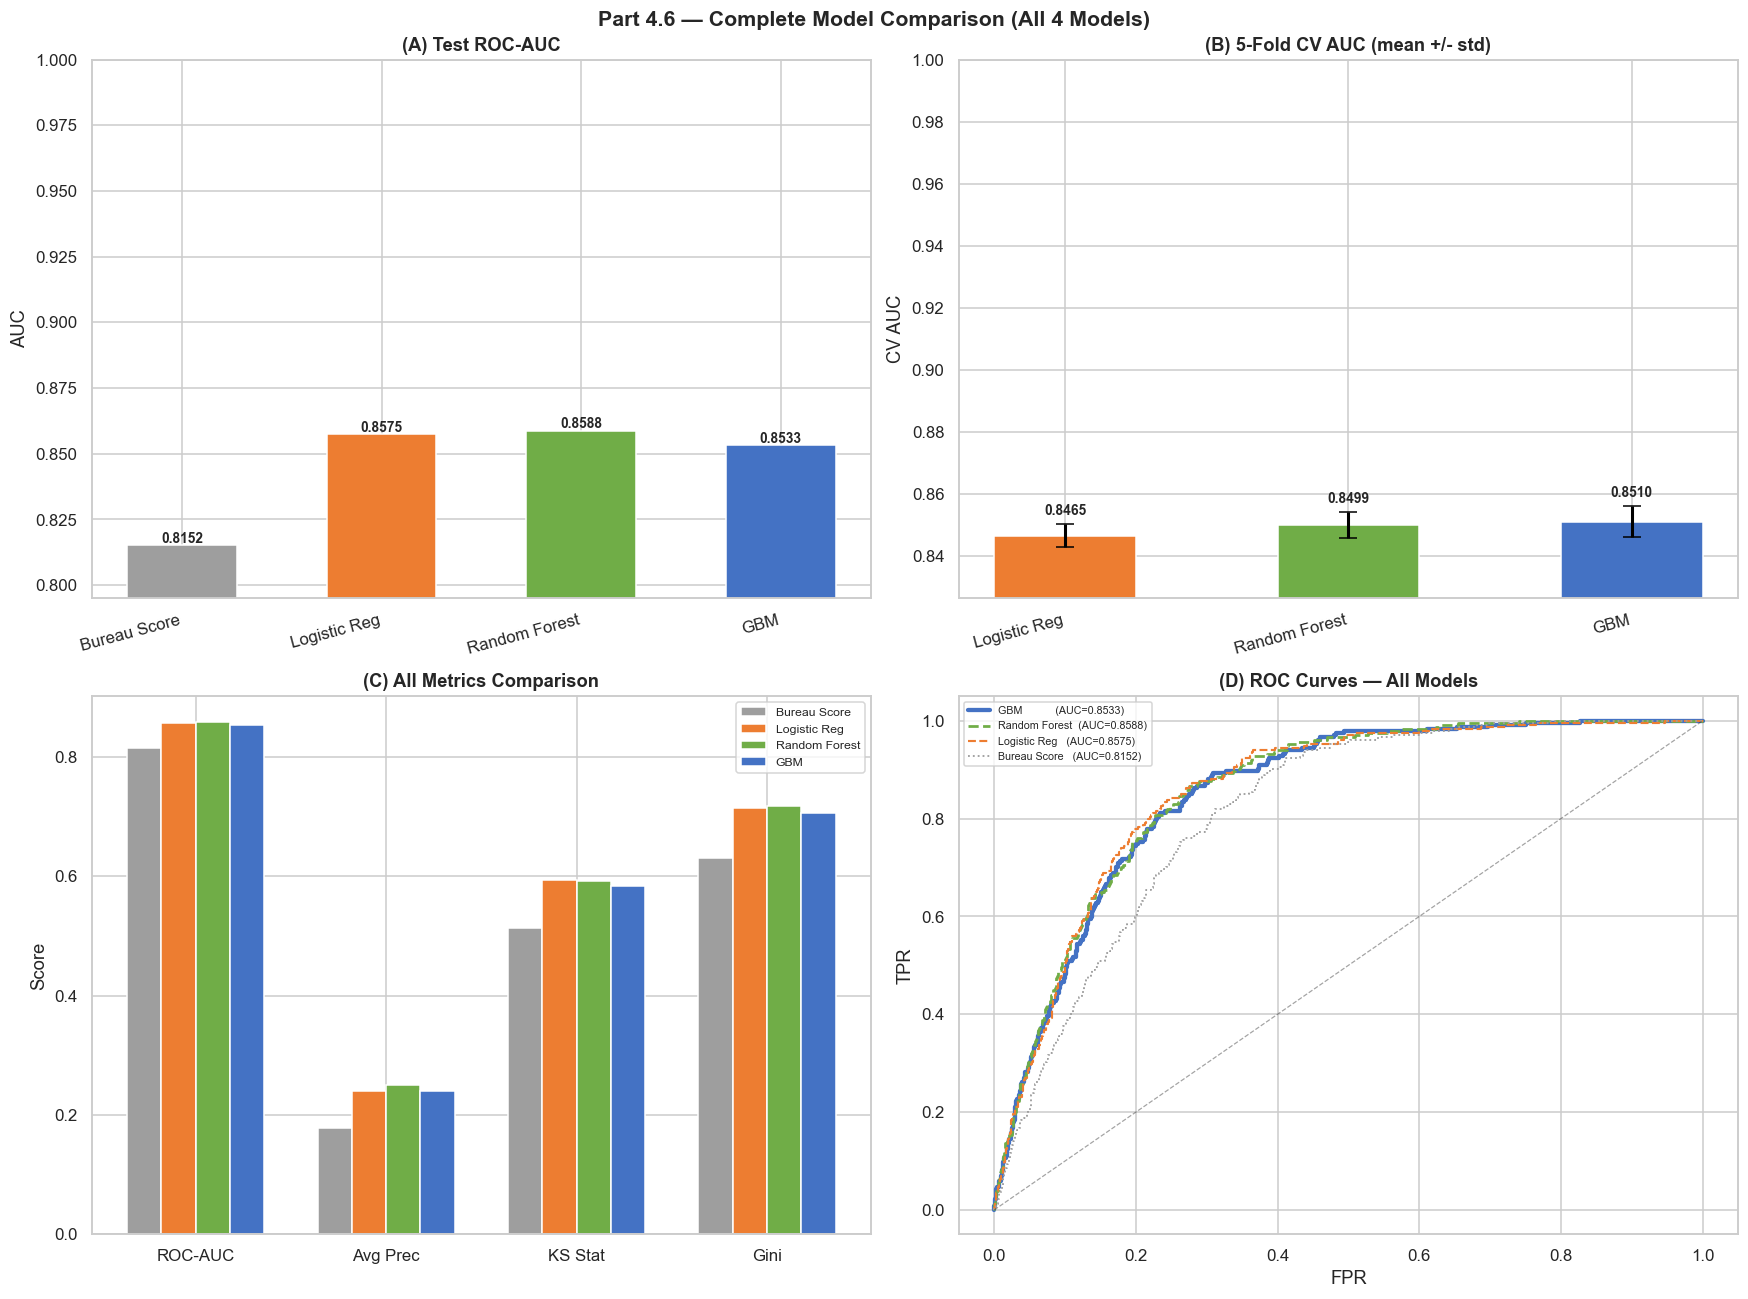

  Model                       AUC       AP       KS     Gini     CV AUC
  ---------------------------------------------------------------
  Bureau Score             0.8152   0.1790   0.5127   0.6305      N/A  
  Logistic Reg             0.8575   0.2397   0.5938   0.7149     0.8465
  Random Forest            0.8588   0.2511   0.5919   0.7177     0.8499
  GBM                      0.8533   0.2401   0.5841   0.7066     0.8510


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Part 4.6 — Complete Model Comparison (All 4 Models)",
             fontsize=14, fontweight="bold")

all_names  = ["Bureau Score", "Logistic Reg", "Random Forest", "GBM"]
all_aucs   = [bureau_auc, lr_auc, rf_auc, test_auc]
all_aps    = [results["Bureau Score (score_1)"]["test_ap"],
              results["Logistic Regression"]["test_ap"],
              results["Random Forest"]["test_ap"],
              test_ap]
all_ks     = [results["Bureau Score (score_1)"]["ks"],
              results["Logistic Regression"]["ks"],
              results["Random Forest"]["ks"],
              ks_val]
all_ginis  = [results["Bureau Score (score_1)"]["gini"],
              results["Logistic Regression"]["gini"],
              results["Random Forest"]["gini"],
              gini]
all_cv     = [None,
              results["Logistic Regression"]["cv_mean"],
              results["Random Forest"]["cv_mean"],
              cv_scores.mean()]
all_cv_std = [None,
              results["Logistic Regression"]["cv_std"],
              results["Random Forest"]["cv_std"],
              cv_scores.std()]
all_colors = [GRAY, ORANGE, GREEN, MODEL_COLOR]

# (A) Test AUC
ax = axes[0, 0]
bars = ax.bar(all_names, all_aucs, color=all_colors, edgecolor="white", width=0.55)
ax.set_ylim(min(all_aucs) - 0.02, 1.0)
ax.set_title("(A) Test ROC-AUC", fontweight="bold"); ax.set_ylabel("AUC")
for bar, val in zip(bars, all_aucs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

# (B) CV AUC with error bars (skip bureau)
ax = axes[0, 1]
cv_names  = all_names[1:]
cv_vals   = all_cv[1:]
cv_stds   = all_cv_std[1:]
cv_cols   = all_colors[1:]
x = np.arange(len(cv_names))
bars = ax.bar(x, cv_vals, yerr=cv_stds, capsize=6,
              color=cv_cols, edgecolor="white", width=0.5,
              error_kw={"elinewidth":2, "ecolor":"black"})
ax.set_xticks(x); ax.set_xticklabels(cv_names, rotation=15, ha="right")
ax.set_ylim(min(cv_vals) - 0.02, 1.0)
ax.set_title("(B) 5-Fold CV AUC (mean +/- std)", fontweight="bold")
ax.set_ylabel("CV AUC")
for bar, val, std in zip(bars, cv_vals, cv_stds):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+std+0.003,
            f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")

# (C) Multi-metric grouped bar
ax = axes[1, 0]
metrics     = [all_aucs, all_aps, all_ks, all_ginis]
metric_lbls = ["ROC-AUC", "Avg Prec", "KS Stat", "Gini"]
x = np.arange(len(metric_lbls)); w = 0.18
for i, (name, color) in enumerate(zip(all_names, all_colors)):
    vals = [m[i] for m in metrics]
    offset = (i - 1.5) * w
    ax.bar(x + offset, vals, w, label=name, color=color, edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(metric_lbls)
ax.set_title("(C) All Metrics Comparison", fontweight="bold")
ax.set_ylabel("Score"); ax.legend(fontsize=8)

# (D) ROC curves all models
ax = axes[1, 1]
for proba, name, color, lw, ls in [
    (proba_test,  f"GBM           (AUC={test_auc:.4f})", MODEL_COLOR, 2.8, "-"),
    (rf_proba,    f"Random Forest  (AUC={rf_auc:.4f})",  GREEN,       1.8, "--"),
    (lr_proba,    f"Logistic Reg   (AUC={lr_auc:.4f})",  ORANGE,      1.4, "--"),
    (bureau_proba,f"Bureau Score   (AUC={bureau_auc:.4f})",GRAY,       1.2, ":"),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=color, lw=lw, linestyle=ls, label=name)
ax.plot([0,1],[0,1], "k--", lw=0.8, alpha=0.4)
ax.set_title("(D) ROC Curves — All Models", fontweight="bold")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# Print summary table
print("=" * 65)
print(f"  {'Model':<22} {'AUC':>8} {'AP':>8} {'KS':>8} {'Gini':>8} {'CV AUC':>10}")
print(f"  {'-'*63}")
for i, name in enumerate(all_names):
    cv_str = f"{all_cv[i]:.4f}" if all_cv[i] else "  N/A  "
    print(f"  {name:<22} {all_aucs[i]:>8.4f} {all_aps[i]:>8.4f} "
          f"{all_ks[i]:>8.4f} {all_ginis[i]:>8.4f} {cv_str:>10}")
print("=" * 65)

## 11 — Store Result & Save

In [11]:
gbm_result = {
    "name"       : MODEL_NAME,
    "color"      : MODEL_COLOR,
    "model"      : gbm,
    "proba_test" : proba_test,
    "test_auc"   : round(test_auc,         4),
    "test_ap"    : round(test_ap,          4),
    "gini"       : round(gini,             4),
    "ks"         : round(ks_val,           4),
    "ks_thresh"  : round(ks_thresh,        4),
    "ks_df"      : ks_df,
    "opt_thresh" : round(opt_thresh,       4),
    "y_pred_opt" : y_pred_opt,
    "cv_mean"    : round(cv_scores.mean(), 4),
    "cv_std"     : round(cv_scores.std(),  4),
    "cv_scores"  : cv_scores.tolist(),
    "train_auc"  : round(train_auc,        4),
    "train_time" : round(train_time,       1),
}

results[MODEL_NAME] = gbm_result
joblib.dump(results, "results_so_far.pkl")
joblib.dump(gbm,     "model_gbm.pkl")

print("Saved:")
print("  results_so_far.pkl  (all 4 models: bureau + LR + RF + GBM)")
print("  model_gbm.pkl       (fitted GBM)")
print()
print("Result summary:")
for k in ["test_auc","test_ap","gini","ks","cv_mean","cv_std","train_auc","train_time"]:
    print(f"  {k:<18}: {gbm_result[k]}")

Saved:
  results_so_far.pkl  (all 4 models: bureau + LR + RF + GBM)
  model_gbm.pkl       (fitted GBM)

Result summary:
  test_auc          : 0.8533
  test_ap           : 0.2401
  gini              : 0.7066
  ks                : 0.5841
  cv_mean           : 0.851
  cv_std            : 0.0049
  train_auc         : 0.9191
  train_time        : 64.4


---
## Summary

### Gradient Boosting Results

| Metric | Value |
|---|---|
| **Test ROC-AUC** | see output |
| **Test Avg Precision** | see output |
| **Gini Coefficient** | see output |
| **KS Statistic** | see output |
| **CV AUC (mean ± std)** | see output |

### Key design decisions recap
- **Low learning rate (0.08) + 100 trees** — converges cleanly without overfitting
- **max_depth=4** — shallow trees are the GBM convention; each tree fixes small errors
- **subsample=0.8** — stochastic GBM reduces variance significantly
- **sample_weight** — passed directly to `.fit()` to correct for 16.3:1 class imbalance

### GBM vs Random Forest — why GBM typically wins
- RF averages independent trees — errors cancel but signal averages too
- GBM fits residuals sequentially — later trees focus exactly where earlier ones failed
- On credit data with noisy features and complex interactions, GBM typically extracts more signal

### What's next
All 4 models are now evaluated. Parts 4.7–4.10 will:
- **4.7** — Select the best model with full justification
- **4.8** — Deep-dive on the winner
- **4.9** — Save artefacts and write the inference script
- **4.10** — Final summary and reflections

---
**Next → Part 4.7: Model Comparison & Best Model Selection**